# Temperature and Student Data Analysis

This notebook analyzes temperature data for three cities using NumPy
and student marks using Python dictionaries.

The objective of this assignment is to practice working with arrays,
dictionaries, loops, and basic data analysis in Python.


Import Libraries

In [2]:
import numpy as np
import pandas as pd

# Dataset 


In [3]:
temps = np.array([
  [30, 32, 31, 29, 28, 27, 26],  # City A
  [22, 21, 23, 24, 25, 26, 24],  # City B
  [15, 17, 16, 18, 19, 20, 21]   # City C
])

temps


array([[30, 32, 31, 29, 28, 27, 26],
       [22, 21, 23, 24, 25, 26, 24],
       [15, 17, 16, 18, 19, 20, 21]])

# Maximum temperature in City A 


In [4]:
cityA_max = np.max(temps[0])

print("Maximum temperature in City A:", cityA_max)

Maximum temperature in City A: 32


# Which day had the highest temperature overall 

In [5]:
max_temp = np.max(temps)

day_index = np.argmax(temps) % 7

print("Highest temperature recorded:", max_temp)
print("Day with highest temperature:", day_index + 1)

Highest temperature recorded: 32
Day with highest temperature: 2


# Compare City A and City B

In [6]:
cityA_avg = np.mean(temps[0])
cityB_avg = np.mean(temps[1])

print("Average City A temperature:", cityA_avg)
print("Average City B temperature:", cityB_avg)

if cityA_avg > cityB_avg:
    print("City A is generally warmer")
else:
    print("City B is generally warmer")

    

Average City A temperature: 29.0
Average City B temperature: 23.571428571428573
City A is generally warmer


# Temperature Comparison 


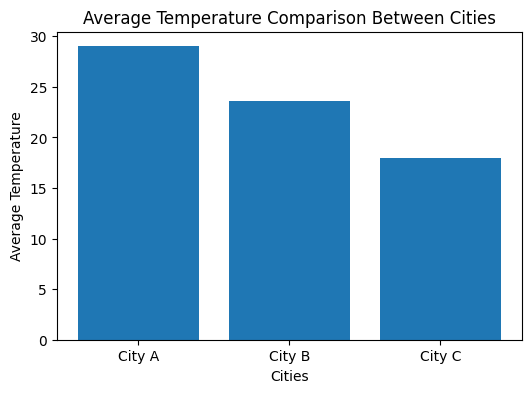

In [13]:
import matplotlib.pyplot as plt
import numpy as np

cities = ["City A","City B","City C"]

avg_temps = [
    np.mean(temps[0]),
    np.mean(temps[1]),
    np.mean(temps[2])
]

plt.figure(figsize=(6,4))

plt.bar(cities,avg_temps)

plt.title("Average Temperature Comparison Between Cities")

plt.xlabel("Cities")

plt.ylabel("Average Temperature")

plt.show()

# Dataset


In [7]:
Student_data = {
"st-1":{"Maths":85,"Urdu":70,"Sindhi":40,"Chemistry":90,"Physics":60},
"st-2":{"Maths":70,"Urdu":75,"Sindhi":40,"Chemistry":90,"Physics":60},
"st-3":{"Maths":80,"Urdu":70,"Sindhi":95,"Chemistry":90,"Physics":60},
"st-4":{"Maths":80,"Urdu":70,"Sindhi":50,"Chemistry":85,"Physics":60},
"st-5":{"Maths":80,"Urdu":75,"Sindhi":40,"Chemistry":90,"Physics":60}
}

Student_data 


{'st-1': {'Maths': 85,
  'Urdu': 70,
  'Sindhi': 40,
  'Chemistry': 90,
  'Physics': 60},
 'st-2': {'Maths': 70,
  'Urdu': 75,
  'Sindhi': 40,
  'Chemistry': 90,
  'Physics': 60},
 'st-3': {'Maths': 80,
  'Urdu': 70,
  'Sindhi': 95,
  'Chemistry': 90,
  'Physics': 60},
 'st-4': {'Maths': 80,
  'Urdu': 70,
  'Sindhi': 50,
  'Chemistry': 85,
  'Physics': 60},
 'st-5': {'Maths': 80,
  'Urdu': 75,
  'Sindhi': 40,
  'Chemistry': 90,
  'Physics': 60}}

# Convert to DataFrame 


In [8]:
df = pd.DataFrame(Student_data).T
df

,Maths,Urdu,Sindhi,Chemistry,Physics
st-1,85,70,40,90,60
st-2,70,75,40,90,60
st-3,80,70,95,90,60
st-4,80,70,50,85,60
st-5,80,75,40,90,60


# Max & Min marks in every subject with StudentID 

In [9]:
for subject in df.columns:
    max_student = df[subject].idxmax()
    min_student = df[subject].idxmin()
    
    print(subject)
    print("Max:", df.loc[max_student, subject], "Student:", max_student)
    print("Min:", df.loc[min_student, subject], "Student:", min_student)
    print()

Maths
Max: 85 Student: st-1
Min: 70 Student: st-2

Urdu
Max: 75 Student: st-2
Min: 70 Student: st-1

Sindhi
Max: 95 Student: st-3
Min: 40 Student: st-1

Chemistry
Max: 90 Student: st-1
Min: 85 Student: st-4

Physics
Max: 60 Student: st-1
Min: 60 Student: st-1



# Max & Min marks of every student 

In [10]:
for student in df.index:
    max_subject = df.loc[student].idxmax()
    min_subject = df.loc[student].idxmin()
    
    print(student)
    print("Highest:", df.loc[student, max_subject], "Subject:", max_subject)
    print("Lowest:", df.loc[student, min_subject], "Subject:", min_subject)
    print()

st-1
Highest: 90 Subject: Chemistry
Lowest: 40 Subject: Sindhi

st-2
Highest: 90 Subject: Chemistry
Lowest: 40 Subject: Sindhi

st-3
Highest: 95 Subject: Sindhi
Lowest: 60 Subject: Physics

st-4
Highest: 85 Subject: Chemistry
Lowest: 50 Subject: Sindhi

st-5
Highest: 90 Subject: Chemistry
Lowest: 40 Subject: Sindhi



# Rank Students by Total Marks


In [11]:
df["Total"] = df.sum(axis=1)

ranking = df.sort_values(by="Total", ascending=False)

ranking

,Maths,Urdu,Sindhi,Chemistry,Physics,Total
st-3,80,70,95,90,60,395
st-1,85,70,40,90,60,345
st-4,80,70,50,85,60,345
st-5,80,75,40,90,60,345
st-2,70,75,40,90,60,335


# Show Student Ranking

In [12]:
ranking["Rank"] = ranking["Total"].rank(ascending=False)

ranking

,Maths,Urdu,Sindhi,Chemistry,Physics,Total,Rank
st-3,80,70,95,90,60,395,1.0
st-1,85,70,40,90,60,345,3.0
st-4,80,70,50,85,60,345,3.0
st-5,80,75,40,90,60,345,3.0
st-2,70,75,40,90,60,335,5.0


# Student Total Marks Ranking

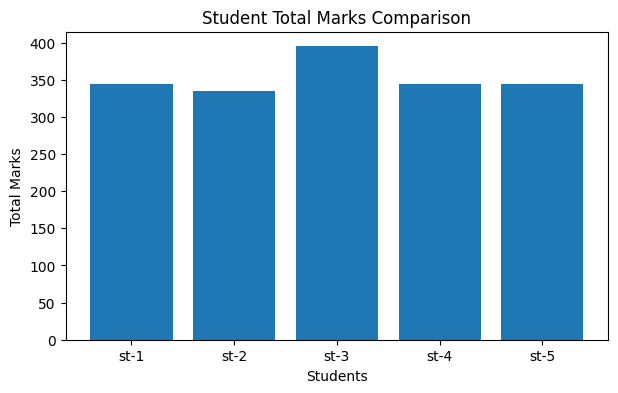

In [14]:
students = df.index
totals = df["Total"]

plt.figure(figsize=(7,4))

plt.bar(students,totals)

plt.title("Student Total Marks Comparison")

plt.xlabel("Students")

plt.ylabel("Total Marks")

plt.show()


## Final Assignment Summary

In this assignment, temperature data and student performance data were analyzed using Python.

For the first task, NumPy arrays were used to analyze the temperature data of three different cities. The analysis included identifying the maximum temperature in City A, determining the day with the highest temperature overall, and comparing the average temperatures of City A and City B to understand which city is generally warmer.

In the second task, a dictionary containing student marks for multiple subjects was analyzed using Python and Pandas. The analysis involved identifying the highest and lowest marks in each subject along with the corresponding student IDs. Additionally, the highest and lowest scoring subjects for each student were determined.

Students were also ranked based on their total marks to evaluate their overall performance.

Finally, graphical visualizations were created to better understand the data patterns. A bar chart was used to compare average temperatures between cities, and another chart was used to visualize student total marks. These visualizations help present the results in a clearer and more professional way.

Overall, this assignment demonstrates practical use of NumPy arrays, dictionaries, loops, and data visualization techniques in Python for basic data analysis tasks.
